# Travel Reimbursement Approval Agent

This is a small prototype for checking travel reimbursement claims against the given policy. I am using normal Python functions for the checks and Azure OpenAI only to create a short explanation from the tool results.


## Setup / README

Install packages if needed:


The notebook reads Azure OpenAI settings from `.env`:

```env
AZURE_OPENAI_API_KEY=your_key
AZURE_OPENAI_ENDPOINT=https://your-resource-name.openai.azure.com/
AZURE_OPENAI_DEPLOYMENT_NAME=your_deployment_name
AZURE_OPENAI_API_VERSION=2024-02-15-preview
```

Run all cells from top to bottom. The last cell prints the final JSON output.


In [ ]:
import os
import json
from datetime import date

import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from openai import AzureOpenAI


## Load Azure OpenAI


In [13]:
load_dotenv()

api_key = os.getenv("AZURE_OPENAI_API_KEY")
api_endpoint = os.getenv("AZURE_OPENAI_ENDPOINT")
api_version = os.getenv("AZURE_OPENAI_API_VERSION", "2024-02-15-preview")
deployment_name = os.getenv("AZURE_OPENAI_DEPLOYMENT_NAME") or os.getenv("AZURE_OPENAI_DEPLOYMENT")
use_azure = os.getenv("USE_AZURE_OPENAI", "true").lower() not in ["false", "0", "no"]

client = None
if use_azure and api_key and api_endpoint and deployment_name:
    client = AzureOpenAI(
        api_key=api_key,
        azure_endpoint=api_endpoint,
        api_version=api_version,
    )
    print("Azure OpenAI client loaded")
else:
    print("Azure OpenAI details not found, using local explanation fallback")


Azure OpenAI client loaded


## Policy And Claims


In [5]:
POLICY = {
    "POL-CAT-01": "Eligible categories are documented business airfare, lodging, meals, ground transport, and conference or registration fees.",
    "POL-CAT-02": "Ineligible items are never reimbursable, including alcohol, minibar, spa, gym, personal entertainment, in-room movies, personal shopping, gifts, traffic fines, penalties, late fees, and personal non-business expenses.",
    "POL-PD-01": "Meals are reimbursable up to USD 75 per day. Amounts above the daily cap are deducted.",
    "POL-PD-02": "Lodging is reimbursable up to USD 200 per night. Amounts above the nightly cap are deducted.",
    "POL-PD-03": "Ground transport is reimbursable up to USD 50 per day. Amounts above the cap are deducted.",
    "POL-AIR-01": "Only economy airfare is reimbursable. Business or first-class airfare is a policy exception and must be routed to Manual Review.",
    "POL-RCT-01": "A receipt is required for any single line item greater than USD 25. Airfare and lodging always require a receipt.",
    "POL-RCT-02": "If a required receipt is missing, route the claim to Manual Review rather than silently rejecting the item.",
    "POL-APR-01": "Total reimbursable amount <= USD 500 may be auto-approved when fully compliant.",
    "POL-APR-02": "Total reimbursable amount > USD 500 and <= USD 2,000 is approvable when fully compliant.",
    "POL-APR-03": "Total reimbursable amount > USD 2,000 exceeds the agent authority and must be routed to Manual Review.",
    "POL-TIME-01": "Claims must be submitted within 30 days of the expense date. Late claims require Manual Review.",
}

CLAIMS = [
    {
        "claim_id": "CLM-001",
        "employee": "A. Rivera",
        "purpose": "Attend 2-day industry conference (business)",
        "trip_start": "2026-06-10",
        "trip_end": "2026-06-12",
        "submitted": "2026-06-20",
        "total": 1110.00,
        "items": [
            {"category": "airfare", "description": "Round-trip economy airfare", "amount": 420.00, "receipt_attached": True, "fare_class": "economy"},
            {"category": "lodging", "description": "Hotel, 2 nights @ $180", "amount": 360.00, "receipt_attached": True, "units": 2},
            {"category": "meals", "description": "Meals, 3 days @ ~$60/day", "amount": 180.00, "receipt_attached": True, "units": 3},
            {"category": "conference_fees", "description": "Conference registration", "amount": 150.00, "receipt_attached": True},
        ],
    },
    {
        "claim_id": "CLM-002",
        "employee": "B. Osei",
        "purpose": "Weekend hotel stay",
        "trip_start": "2026-06-14",
        "trip_end": "2026-06-15",
        "submitted": "2026-06-25",
        "total": 380.00,
        "items": [
            {"category": "spa", "description": "Hotel spa package", "amount": 300.00, "receipt_attached": True},
            {"category": "minibar", "description": "In-room minibar", "amount": 80.00, "receipt_attached": True},
        ],
    },
    {
        "claim_id": "CLM-003",
        "employee": "C. Nakamura",
        "purpose": "Client site visit (business)",
        "trip_start": "2026-06-08",
        "trip_end": "2026-06-10",
        "submitted": "2026-06-22",
        "total": 940.00,
        "items": [
            {"category": "airfare", "description": "Round-trip economy airfare", "amount": 300.00, "receipt_attached": True, "fare_class": "economy"},
            {"category": "lodging", "description": "Hotel, 2 nights @ $250", "amount": 500.00, "receipt_attached": True, "units": 2},
            {"category": "meals", "description": "Meals, 2 days @ $70/day", "amount": 140.00, "receipt_attached": True, "units": 2},
        ],
    },
    {
        "claim_id": "CLM-004",
        "employee": "D. Fischer",
        "purpose": "International vendor negotiation (business)",
        "trip_start": "2026-06-16",
        "trip_end": "2026-06-18",
        "submitted": "2026-06-28",
        "total": 3000.00,
        "items": [
            {"category": "airfare", "description": "Business-class international airfare", "amount": 2400.00, "receipt_attached": True, "fare_class": "business"},
            {"category": "lodging", "description": "Hotel, 3 nights", "amount": 600.00, "receipt_attached": False, "units": 3},
        ],
    },
    {
        "claim_id": "CLM-005",
        "employee": "E. Haddad",
        "purpose": "Client dinner / business development",
        "trip_start": "2026-06-11",
        "trip_end": "2026-06-11",
        "submitted": "2026-06-24",
        "total": 220.00,
        "items": [
            {"category": "meals", "description": "Client dinner for 4 (business development)", "amount": 220.00, "receipt_attached": False, "units": 1, "attendees": 4},
        ],
    },
]

print(f"Loaded {len(CLAIMS)} claims and {len(POLICY)} policy rules.")


Loaded 5 claims and 12 policy rules.


## Tool Functions

These are the tools used by the agent workflow.


In [14]:
def policy_lookup(policy_ids):
    found = {}
    for policy_id in policy_ids:
        if policy_id in POLICY:
            found[policy_id] = POLICY[policy_id]
    return found


def category_eligibility_checker(item):
    eligible = ["airfare", "lodging", "meals", "ground_transport", "taxi", "rideshare", "train", "rental_car", "parking", "conference_fees"]
    ineligible = ["alcohol", "minibar", "spa", "gym", "personal_entertainment", "in_room_movies", "personal_shopping", "gifts", "traffic_fines", "penalties", "late_fees", "personal"]

    category = item["category"]
    if category in ineligible:
        return {
            "tool": "category_eligibility_checker",
            "eligible": False,
            "manual_review": False,
            "approved_amount": 0.0,
            "deducted_amount": float(item["amount"]),
            "policy_refs": ["POL-CAT-02"],
            "message": category + " is not reimbursable"
        }

    if category in eligible:
        return {
            "tool": "category_eligibility_checker",
            "eligible": True,
            "manual_review": False,
            "approved_amount": float(item["amount"]),
            "deducted_amount": 0.0,
            "policy_refs": ["POL-CAT-01"],
            "message": category + " is eligible"
        }

    return {
        "tool": "category_eligibility_checker",
        "eligible": False,
        "manual_review": True,
        "approved_amount": 0.0,
        "deducted_amount": 0.0,
        "policy_refs": ["POL-CAT-01"],
        "message": category + " needs manual review"
    }


def receipt_checker(item):
    receipt_required = item["amount"] > 25 or item["category"] in ["airfare", "lodging"]
    receipt_attached = item.get("receipt_attached", False)

    if receipt_required and not receipt_attached:
        return {
            "tool": "receipt_checker",
            "manual_review": True,
            "missing_doc": item["category"] + "_receipt",
            "policy_refs": ["POL-RCT-01", "POL-RCT-02"],
            "message": "receipt is missing"
        }

    return {
        "tool": "receipt_checker",
        "manual_review": False,
        "missing_doc": None,
        "policy_refs": ["POL-RCT-01"],
        "message": "receipt check passed"
    }


def per_diem_limit_checker(item):
    category = item["category"]
    amount = float(item["amount"])
    units = int(item.get("units", 1))

    if category == "meals":
        allowed = 75 * units
        return {
            "tool": "per_diem_limit_checker",
            "approved_amount": round(min(amount, allowed), 2),
            "deducted_amount": round(max(0, amount - allowed), 2),
            "policy_refs": ["POL-PD-01"],
            "message": "meal cap checked"
        }

    if category == "lodging":
        allowed = 200 * units
        return {
            "tool": "per_diem_limit_checker",
            "approved_amount": round(min(amount, allowed), 2),
            "deducted_amount": round(max(0, amount - allowed), 2),
            "policy_refs": ["POL-PD-02"],
            "message": "lodging cap checked"
        }

    if category in ["ground_transport", "taxi", "rideshare", "train", "rental_car", "parking"]:
        allowed = 50 * units
        return {
            "tool": "per_diem_limit_checker",
            "approved_amount": round(min(amount, allowed), 2),
            "deducted_amount": round(max(0, amount - allowed), 2),
            "policy_refs": ["POL-PD-03"],
            "message": "ground transport cap checked"
        }

    return {
        "tool": "per_diem_limit_checker",
        "approved_amount": amount,
        "deducted_amount": 0.0,
        "policy_refs": [],
        "message": "no per-diem limit"
    }


def airfare_class_checker(item):
    if item["category"] != "airfare":
        return {"tool": "airfare_class_checker", "manual_review": False, "policy_refs": [], "message": "not airfare"}

    fare_class = item.get("fare_class", "").lower()
    if fare_class != "economy":
        return {"tool": "airfare_class_checker", "manual_review": True, "policy_refs": ["POL-AIR-01"], "message": "airfare class needs manual review"}

    return {"tool": "airfare_class_checker", "manual_review": False, "policy_refs": ["POL-AIR-01"], "message": "economy airfare"}


def timeliness_checker(claim):
    submitted = date.fromisoformat(claim["submitted"])
    trip_end = date.fromisoformat(claim["trip_end"])
    days = (submitted - trip_end).days

    return {
        "tool": "timeliness_checker",
        "manual_review": days > 30,
        "policy_refs": ["POL-TIME-01"],
        "message": "submitted in " + str(days) + " days"
    }


def approval_threshold_checker(amount):
    if amount > 2000:
        return {"tool": "approval_threshold_checker", "manual_review": True, "policy_refs": ["POL-APR-03"], "message": "director/manual review tier"}
    if amount > 500:
        return {"tool": "approval_threshold_checker", "manual_review": False, "policy_refs": ["POL-APR-02"], "message": "manager tier"}
    return {"tool": "approval_threshold_checker", "manual_review": False, "policy_refs": ["POL-APR-01"], "message": "auto approve tier"}


## Agent Workflow

The workflow calls the tools, keeps the policy references, and then decides the final status.


In [15]:
def fallback_explanation(result):
    if result["decision"] == "APPROVE":
        return "Claim is compliant with the policy and can be approved."
    if result["decision"] == "PARTIAL_APPROVE":
        return "Claim is mostly valid, but some amount is above the allowed policy limit."
    if result["decision"] == "REJECT":
        return "Claim is rejected because the submitted items are not reimbursable."
    return "Claim needs manual review because of missing receipt, approval threshold, exception, or ambiguity."


def get_llm_explanation(claim, result, tool_outputs):
    if client is None:
        return fallback_explanation(result)

    prompt = f"""
Claim:
{json.dumps(claim, indent=2)}

Tool output:
{json.dumps(tool_outputs, indent=2)}

Final result:
{json.dumps(result, indent=2)}

Explain the decision in 1-2 lines. Use only the given policy refs.
"""
    try:
        response = client.chat.completions.create(
            model=deployment_name,
            messages=[
                {"role": "system", "content": "You explain travel reimbursement decisions."},
                {"role": "user", "content": prompt}
            ],
            temperature=0,
            max_tokens=120,
        )
        return response.choices[0].message.content.strip()
    except Exception:
        return fallback_explanation(result)


def evaluate_claim(claim):
    approved_amount = 0.0
    deducted_amount = 0.0
    missing_docs = []
    policy_refs = []
    tools_used = []
    tool_outputs = []
    manual_review = False
    eligible_count = 0
    ineligible_count = 0

    time_result = timeliness_checker(claim)
    tool_outputs.append(time_result)
    tools_used.append(time_result["tool"])
    policy_refs.extend(time_result["policy_refs"])
    if time_result["manual_review"]:
        manual_review = True

    for item in claim["items"]:
        category_result = category_eligibility_checker(item)
        tool_outputs.append(category_result)
        tools_used.append(category_result["tool"])
        policy_refs.extend(category_result["policy_refs"])

        if category_result["manual_review"]:
            manual_review = True
            continue

        if not category_result["eligible"]:
            ineligible_count += 1
            deducted_amount += category_result["deducted_amount"]
            continue

        eligible_count += 1

        receipt_result = receipt_checker(item)
        tool_outputs.append(receipt_result)
        tools_used.append(receipt_result["tool"])
        policy_refs.extend(receipt_result["policy_refs"])
        if receipt_result["manual_review"]:
            manual_review = True
            missing_docs.append(receipt_result["missing_doc"])

        airfare_result = airfare_class_checker(item)
        tool_outputs.append(airfare_result)
        tools_used.append(airfare_result["tool"])
        policy_refs.extend(airfare_result["policy_refs"])
        if airfare_result["manual_review"]:
            manual_review = True

        limit_result = per_diem_limit_checker(item)
        tool_outputs.append(limit_result)
        tools_used.append(limit_result["tool"])
        policy_refs.extend(limit_result["policy_refs"])
        approved_amount += limit_result["approved_amount"]
        deducted_amount += limit_result["deducted_amount"]

    threshold_result = approval_threshold_checker(approved_amount)
    tool_outputs.append(threshold_result)
    tools_used.append(threshold_result["tool"])
    policy_refs.extend(threshold_result["policy_refs"])
    if threshold_result["manual_review"]:
        manual_review = True

    if manual_review:
        decision = "MANUAL_REVIEW"
    elif eligible_count == 0 and ineligible_count > 0:
        decision = "REJECT"
        approved_amount = 0.0
    elif deducted_amount > 0:
        decision = "PARTIAL_APPROVE"
    else:
        decision = "APPROVE"

    result = {
        "claim_id": claim["claim_id"],
        "decision": decision,
        "approved_amount": round(float(approved_amount), 2),
        "deducted_amount": round(float(deducted_amount), 2),
        "missing_docs": sorted(list(set([doc for doc in missing_docs if doc]))),
        "policy_refs": sorted(list(set(policy_refs))),
        "confidence": 0.75 if decision == "MANUAL_REVIEW" else 0.90,
        "explanation": "",
        "tools_used": sorted(list(set(tools_used))),
    }

    result["explanation"] = get_llm_explanation(claim, result, tool_outputs)
    return result


## Run The Agent


In [16]:
results = []

for claim in CLAIMS:
    result = evaluate_claim(claim)
    results.append(result)

pd.DataFrame(results)


,claim_id,decision,approved_amount,deducted_amount,missing_docs,policy_refs,confidence,explanation,tools_used
0,CLM-001,APPROVE,1110.0,0.0,[],"[POL-AIR-01, POL-APR-02, POL-CAT-01, POL-PD-01...",0.90,Claim is compliant with the policy and can be ...,"[airfare_class_checker, approval_threshold_che..."
1,CLM-002,REJECT,0.0,380.0,[],"[POL-APR-01, POL-CAT-02, POL-TIME-01]",0.90,Claim is rejected because the submitted items ...,"[approval_threshold_checker, category_eligibil..."
2,CLM-003,PARTIAL_APPROVE,840.0,100.0,[],"[POL-AIR-01, POL-APR-02, POL-CAT-01, POL-PD-01...",0.90,"Claim is mostly valid, but some amount is abov...","[airfare_class_checker, approval_threshold_che..."
3,CLM-004,MANUAL_REVIEW,3000.0,0.0,[lodging_receipt],"[POL-AIR-01, POL-APR-03, POL-CAT-01, POL-PD-02...",0.75,Claim needs manual review because of missing r...,"[airfare_class_checker, approval_threshold_che..."
4,CLM-005,MANUAL_REVIEW,75.0,145.0,[meals_receipt],"[POL-APR-01, POL-CAT-01, POL-PD-01, POL-RCT-01...",0.75,Claim needs manual review because of missing r...,"[airfare_class_checker, approval_threshold_che..."


## Validate Output


In [17]:
required_keys = [
    "claim_id", "decision", "approved_amount", "deducted_amount",
    "missing_docs", "policy_refs", "confidence", "explanation", "tools_used"
]
allowed_decisions = ["APPROVE", "PARTIAL_APPROVE", "REJECT", "MANUAL_REVIEW"]


def output_validator(result):
    assert list(result.keys()) == required_keys
    assert result["decision"] in allowed_decisions
    assert isinstance(result["missing_docs"], list)
    assert isinstance(result["policy_refs"], list)
    assert isinstance(result["tools_used"], list)
    return True


for result in results:
    output_validator(result)

print("All outputs are valid")


All outputs are valid


## Dashboard


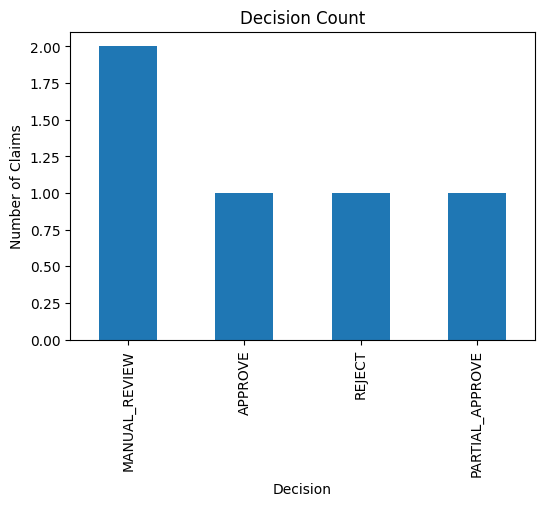

,claim_id,approved_amount,deducted_amount
0,CLM-001,1110.0,0.0
1,CLM-002,0.0,380.0
2,CLM-003,840.0,100.0
3,CLM-004,3000.0,0.0
4,CLM-005,75.0,145.0


In [18]:
results_df = pd.DataFrame(results)

plt.figure(figsize=(6, 4))
results_df["decision"].value_counts().plot(kind="bar")
plt.title("Decision Count")
plt.xlabel("Decision")
plt.ylabel("Number of Claims")
plt.show()

results_df[["claim_id", "approved_amount", "deducted_amount"]]


## Sample Outputs


In [19]:
results_df[["claim_id", "decision", "approved_amount", "deducted_amount", "missing_docs"]].head(5)


,claim_id,decision,approved_amount,deducted_amount,missing_docs
0,CLM-001,APPROVE,1110.0,0.0,[]
1,CLM-002,REJECT,0.0,380.0,[]
2,CLM-003,PARTIAL_APPROVE,840.0,100.0,[]
3,CLM-004,MANUAL_REVIEW,3000.0,0.0,[lodging_receipt]
4,CLM-005,MANUAL_REVIEW,75.0,145.0,[meals_receipt]


## Design Notes & Reasoning

- I used Python functions as tools so the amount calculations and policy checks are predictable.
- Azure OpenAI is used only for writing the explanation. If the API is not available, a simple fallback explanation is used.
- Missing receipts, business-class airfare, late claims, high-value claims, and unknown cases go to `MANUAL_REVIEW`.
- `PARTIAL_APPROVE` is used when the claim is valid but a per-diem cap deducts some amount.
- This is a notebook prototype, so I kept the data in the notebook and did not add a database or backend service.
- Improvements: add receipt OCR, duplicate claim checking, and a small form-based UI.


## Final JSON Output


In [20]:
print(json.dumps(results, indent=2))


[
  {
    "claim_id": "CLM-001",
    "decision": "APPROVE",
    "approved_amount": 1110.0,
    "deducted_amount": 0.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-AIR-01",
      "POL-APR-02",
      "POL-CAT-01",
      "POL-PD-01",
      "POL-PD-02",
      "POL-RCT-01",
      "POL-TIME-01"
    ],
    "confidence": 0.9,
    "explanation": "Claim is compliant with the policy and can be approved.",
    "tools_used": [
      "airfare_class_checker",
      "approval_threshold_checker",
      "category_eligibility_checker",
      "per_diem_limit_checker",
      "receipt_checker",
      "timeliness_checker"
    ]
  },
  {
    "claim_id": "CLM-002",
    "decision": "REJECT",
    "approved_amount": 0.0,
    "deducted_amount": 380.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-APR-01",
      "POL-CAT-02",
      "POL-TIME-01"
    ],
    "confidence": 0.9,
    "explanation": "Claim is rejected because the submitted items are not reimbursable.",
    "tools_used": [
      "app